# Using a static graph

Rather than generating a directed acyclic graph automatically and interpolating gridded meteorology data at samples along edges, the optimizer can use a precomputed static graph that stores meteorology data directly on edges rather than in a separate gridded dataset. This can reduce the cost of constructing optimizers by avoiding the need to re-interpolate gridded met data for every origin-destination pair.

This notebook shows how to define a simple static graph and use it for 4D optimization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pycontrails.physics import units

import contrailopt as co

## Static graph

Static graphs are represented by xarray Datasets that hold variables to define the graph and to represent met data interpolated onto the graph.

In [2]:
graph = xr.Dataset()

Locations of waypoints (nodes in the graph) are represented by ``lon`` and ``lat`` variables that hold longitude and latitude coordinates.

In [3]:
lat = [47.45, 47.45, 42.36, 42.36]
lon = [-122.31, -100.0, -100.0, -71.01]

graph["node"] = (("node",), range(4))
graph["lon"] = (("node",), lon)
graph["lat"] = (("node",), lat)

Locations of airports are represented by an ``airport_node`` variable that maps ICAO codes to node coordinates.

While this graph only includes two airports (Seattle and Boston), the optimizer can use static graphs that contain any number of airports.

In [4]:
graph["icao"] = (("icao",), ["KSEA", "KBOS"])
graph["airport_node"] = (("icao",), [0, 3])

Routes between waypoints (edges between nodes) are represented by ``tail`` and ``head`` variables that contain node coordinates of the start and end of each edge. The optimizer interprets these routes as edges in an __undirected__ graph and allows flights to traverse edges in either direction.

These edges define two routes (one northern and one southern) between Seattle and Boston.

In [5]:
graph["edge"] = (("edge",), range(4))
graph["tail"] = (("edge",), [0, 0, 1, 2])
graph["head"] = (("edge",), [1, 2, 3, 3])

Finally, meteorology is represented by ``air_temperature``, ``tailwind``, and (optionally) ``eef_per_m`` variables. These variables represent distance-weighted averages of air temperature, tailwind, and energy forcing per unit flight distance over each edge. The ``tailwind`` variable represents the tailwind component when traveling from ``tail`` to ``head`` nodes and is automatically reversed by the optimizer when flying from ``head`` to ``tail`` nodes.

Each variable contains ``level`` and ``time`` as additional coordinates that must cover the range of allowable cruise levels from takeoff to landing. 

In [6]:
flight_level = np.arange(240, 450, 10)
level = units.ft_to_pl(flight_level * 100)
time = pd.date_range("2026-03-07T00:00:00", "2026-03-07T12:00:00", freq="1h")

graph["level"] = (("level",), level)
graph["time"] = (("time",), time)

In this example, ``air_temperature`` follows the ISA profile.

In [7]:
air_temperature = units.m_to_T_isa(units.pl_to_m(level))
air_temperature = air_temperature.reshape((1, -1, 1))
air_temperature = np.tile(air_temperature, (4, 1, time.size))

graph["air_temperature"] = (("edge", "level", "time"), air_temperature)

The ``tailwind`` variable specifies a 50 m/s tailwind from Seattle to Boston along the northern route and a 10 m/s headwind along the southern route.

In [8]:
tailwind = np.array([50, 10, 50, 10])
tailwind = tailwind.reshape((-1, 1, 1))
tailwind = np.tile(tailwind, (1, level.size, time.size))

graph["tailwind"] = (("edge", "level", "time"), tailwind)

Energy forcing per unit flight distance is set to $10^9$ J/m along the southern route between FL350 and FL370 and zero elsewhere.

In [9]:
eef_per_m = np.where((flight_level >= 350) & (flight_level <= 370), 1e9, 0.0)
eef_per_m = eef_per_m.reshape((1, -1, 1))
eef_per_m = np.tile(eef_per_m, (4, 1, time.size))
eef_per_m[0::2, :, :] = 0.0

graph["eef_per_m"] = (("edge", "level", "time"), eef_per_m)

In [10]:
graph

<xarray.Dataset> Size: 27kB
Dimensions:          (node: 4, icao: 2, edge: 4, level: 21, time: 13)
Coordinates:
  * node             (node) int64 32B 0 1 2 3
  * icao             (icao) <U4 32B 'KSEA' 'KBOS'
  * edge             (edge) int64 32B 0 1 2 3
  * level            (level) float64 168B 392.7 376.0 359.9 ... 162.4 154.7
  * time             (time) datetime64[us] 104B 2026-03-07 ... 2026-03-07T12:...
Data variables:
    lon              (node) float64 32B -122.3 -100.0 -100.0 -71.01
    lat              (node) float64 32B 47.45 47.45 42.36 42.36
    airport_node     (icao) int64 16B 0 3
    tail             (edge) int64 32B 0 0 1 2
    head             (edge) int64 32B 1 2 3 3
    air_temperature  (edge, level, time) float64 9kB 240.6 240.6 ... 216.6 216.6
    tailwind         (edge, level, time) int64 9kB 50 50 50 50 ... 10 10 10 10
    eef_per_m        (edge, level, time) float64 9kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

## Example 1: Seattle to Boston, no contrail costs

The optimizer sends flights from Seattle to Boston along the northern route to take advantage of the favorable tailwind.

In [11]:
seattle = co.AirportCoords.from_icao("KSEA")
boston = co.AirportCoords.from_icao("KBOS")
aircraft_type = "B737"
takeoff_time = pd.Timestamp("2026-03-07T02:00:00")

In [12]:
opt = co.Optimizer(
    origin_icao=seattle,
    dest_icao=boston,
    static_graph=graph,
    aircraft_type=aircraft_type,
    takeoff_time=takeoff_time,
)

opt

Optimizer(KSEA -> KBOS, B737, 2026-03-07 02:00:00, 4 nodes, with met, unsolved)

In [13]:
res = opt.solve(cost_index=30)

By default, calling ``opt.to_flight()`` when using a static graph returns waypoints at the start and end of each edge only. Using the ``resample_m`` argument resamples edges at the specified frequency and accurately represents step climbs and descents in the optimized trajectory. No meteorology is attached to the resampled flight when ``resample_m`` is used.

Note that the optimizer only allows a single step climb or descent at the start of each edge. This solution flies the first edge at FL370 and steps to FL390 at the start of the second edge. Adding additional nodes to increase the number of individual edges might result in more steps.

In [14]:
fl = opt.to_flight(resample_m=25_000)

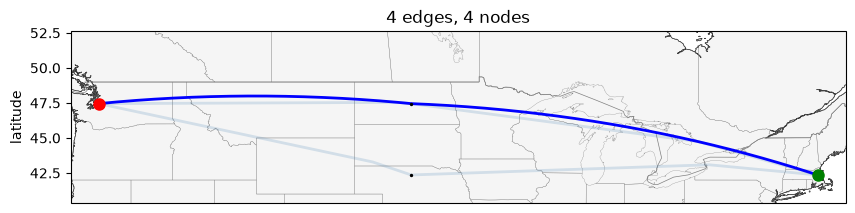

In [15]:
ax = opt.dag.plot()
fl.plot(ax=ax, linewidth=2, color="blue")
ax.get_figure().set_size_inches(10, 6)

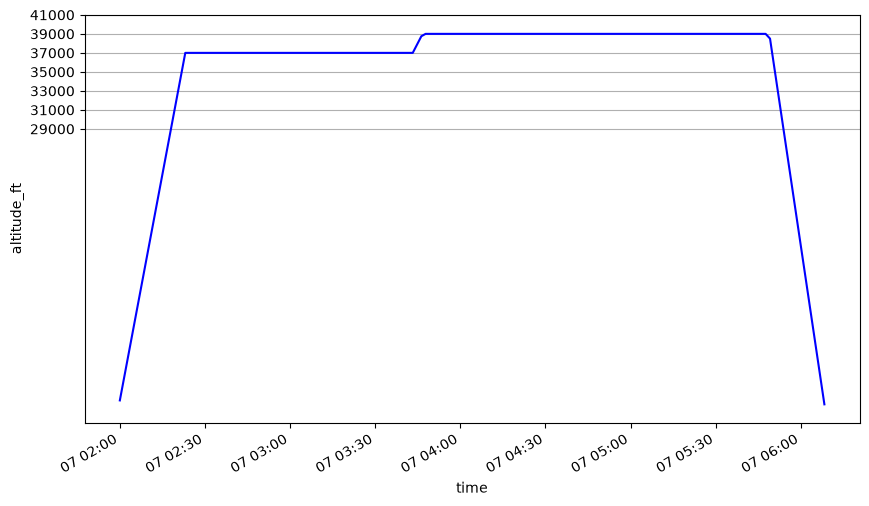

In [16]:
ax = fl.plot_profile(color="blue")
ax.set_yticks(opt.fl_choices)
ax.grid(True, axis="y")
ax.get_figure().set_size_inches(10, 6)

## Example 2: Boston to Seattle, no contrail costs

When flying in the opposite direction, the optimizer uses the southern route to avoid a strong headwind.

In [17]:
opt = co.Optimizer(
    origin_icao=boston,
    dest_icao=seattle,
    static_graph=graph,
    aircraft_type=aircraft_type,
    takeoff_time=takeoff_time,
)

res = opt.solve(cost_index=30)

In [18]:
fl = opt.to_flight(resample_m=25_000)

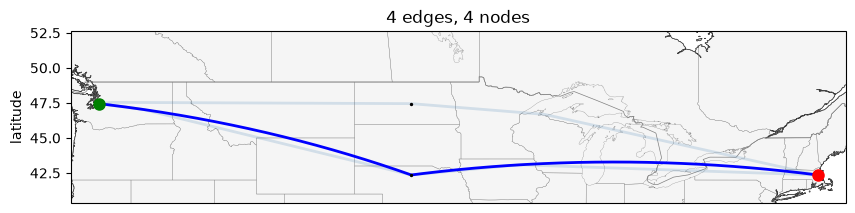

In [19]:
ax = opt.dag.plot()
fl.plot(ax=ax, linewidth=2, color="blue")
ax.get_figure().set_size_inches(10, 6)

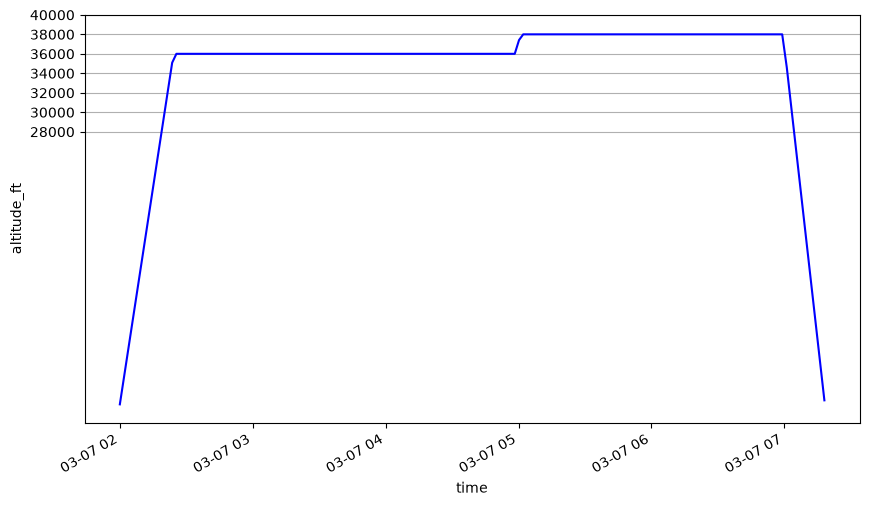

In [20]:
ax = fl.plot_profile(color="blue")
ax.set_yticks(opt.fl_choices)
ax.grid(True, axis="y")
ax.get_figure().set_size_inches(10, 6)

## Example 3: Boston to Seattle, including contrail costs

The cost-optimal route from Boston to Seattle includes a leg (the first edge at FL360) with strong contrail warming. It can be avoided in one of two ways: by remaining on the southern route but choosing a different flight level, or by moving to the northern route.

The optimizer chooses to fly the southern route with the first leg at FL340, which results in a lower total cost than fighting the strong headwind on the northern route.

In [21]:
opt = co.Optimizer(
    origin_icao=boston,
    dest_icao=seattle,
    static_graph=graph,
    aircraft_type=aircraft_type,
    takeoff_time=takeoff_time,
)

res = opt.solve(cost_index=30, dollar_tonne_co2e=10)

In [22]:
fl = opt.to_flight(resample_m=25_000)

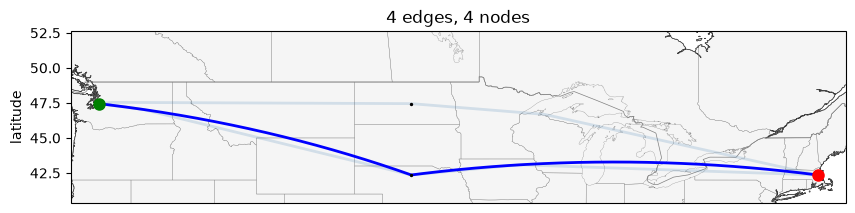

In [23]:
ax = opt.dag.plot()
fl.plot(ax=ax, linewidth=2, color="blue")
ax.get_figure().set_size_inches(10, 6)

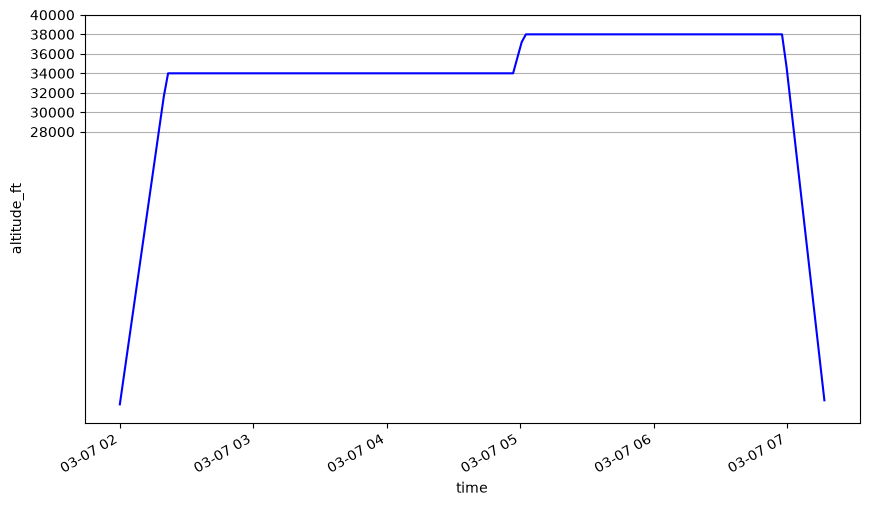

In [24]:
ax = fl.plot_profile(color="blue")
ax.set_yticks(opt.fl_choices)
ax.grid(True, axis="y")
ax.get_figure().set_size_inches(10, 6)

## Example 4: invalid inputs

The optimizer attempts to fail early and gracefully when the dataset representing the static graph is missing required information...

In [25]:
try:
    opt = co.Optimizer(
        origin_icao=boston,
        dest_icao=seattle,
        static_graph=graph.drop_vars("tail"),
        aircraft_type=aircraft_type,
        takeoff_time=takeoff_time,
    )
except ValueError as e:
    print(e)

Static graph missing required variable 'tail'


... or when the origin or destination is not included in the graph:

In [26]:
try:
    opt = co.Optimizer(
        origin_icao="KJFK",
        dest_icao=seattle,
        static_graph=graph,
        aircraft_type=aircraft_type,
        takeoff_time=takeoff_time,
    )
except ValueError as e:
    print(e)

Origin KJFK is not included in static graph.
